# Majority Voting Recommendation

This notebook implements the Majority Voting (MV) evaluation strategy for the encoding circuit recommendation framework. An ensemble of 14 classical classifiers votes on the recommended encoding circuit for a given dataset, based on its complexity metrics.

**Inputs:** CSV files from `Quantum_Learning.ipynb` (complexity metrics + ground truth labels).

**Outputs:** MV accuracy for Task-A and Task-B, per-metric and all-metrics comparisons.

In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.base import clone

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    AdaBoostClassifier, 
    BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

## 1. Setup

14 meta-learners spanning diverse classifier families: tree-based (DT, RF, Gradient Boosting, AdaBoost, Bagging), kernel-based (SVM with linear/RBF/sigmoid kernels), neural (MLP with two architectures), instance-based (kNN, NearestCentroid), probabilistic (NaiveBayes), and linear (LogisticRegression).

In [2]:
CLASSIFIERS = {
    'DT': DecisionTreeClassifier(random_state=42),
    'RF': RandomForestClassifier(n_estimators=10, random_state=42),
    'Ensemble-GB': GradientBoostingClassifier(random_state=42),
    'Ensemble-AB': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42), 
        n_estimators=50, 
        random_state=42,
        algorithm='SAMME'
    ),
    'Ensemble-Bg': BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=10,
        random_state=42
    ),
    'SVM-Linear': SVC(kernel='linear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'SVM-Sigmoid': SVC(kernel='sigmoid', C=1.0, gamma='scale', random_state=42),
    'MLP-500': MLPClassifier(hidden_layer_sizes=(500,), max_iter=1000, random_state=42),
    'MLP-100-100-100': MLPClassifier(hidden_layer_sizes=(100,100,100), max_iter=1000, random_state=42),
    'kNN': KNeighborsClassifier(n_neighbors=5),
    'NearestCentroid': NearestCentroid(),
    'NaiveBayes': GaussianNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
}

## 2. Data Loading

Load the synthesis DataFrame (24 complexity metrics per dataset) and ground truth labels for both task formulations:
- **Task-A**: single best encoding circuit per dataset
- **Task-B**: all encoding circuits within a tolerance threshold of the best accuracy

In [2]:
TEST_SIZE = 0.2
N_RUNS = 10
RANDOM_STATE = 42

METRIC_NAMES = [
    'f1', 'f1v', 'f2', 'f3', 'f4', 'l1', 'l2', 'l3',
    'n1', 'n2', 'n3', 'n4', 't1', 'lsc', 'density',
    'clsCoef', 'hubs', 't2', 't3', 't4', 'c1', 'c2',
    'kolmogorov', 'intrinsic'
]

In [3]:
synthesis_df = pd.read_csv("results/synthesis_df.csv", index_col=0)
taska_labels = pd.read_csv("results/taska_labels.csv")
taskb_labels = pd.read_csv("results/taskb_labels.csv")

print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"Synthesis DataFrame: {synthesis_df.shape}")
print(f"Task-A Labels: {len(taska_labels)}")
print(f"Task-B Labels: {len(taskb_labels)}")
print(f"\nFeatures: {len(synthesis_df.columns) - 1}")
print(f"Unique Kernels: {taska_labels['Best_Kernel'].nunique()}")
print("\nKernel Distribution (Task-A):")
print(taska_labels['Best_Kernel'].value_counts())
print("\nKernel Distribution (Task-B):")
print(taskb_labels['Best_Kernel'].value_counts())

DATA SUMMARY
Synthesis DataFrame: (200, 25)
Task-A Labels: 200
Task-B Labels: 442

Features: 24
Unique Kernels: 8

Kernel Distribution (Task-A):
Best_Kernel
HighDim                66
ZFeatureMap            44
HZY_CZ                 26
HardwareEfficientRx    23
ZZFeatureMap           19
SeparableRX            18
ParamZFeatureMap        3
Chebyshev               1
Name: count, dtype: int64

Kernel Distribution (Task-B):
Best_Kernel
HighDim                89
ZFeatureMap            89
HardwareEfficientRx    85
SeparableRX            74
HZY_CZ                 58
ZZFeatureMap           42
ParamZFeatureMap        3
Chebyshev               2
Name: count, dtype: int64


## 3. Core Functions

Majority Voting inference: each of the 14 classifiers independently predicts an encoding circuit label, and the label receiving the most votes is selected as the final recommendation.

In [5]:
def predict_majority_vote(X, trained_models):
    all_predictions = []
    for i in range(X.shape[0]):
        votes = []
        for name, model in trained_models.items():
            pred = model.predict(X[i:i+1])[0]
            votes.append(pred)
        vote_counts = Counter(votes) # calculate the frequency of each labels
        majority = vote_counts.most_common(1)[0][0]
        all_predictions.append(majority)
    return np.array(all_predictions)

def predict_with_details(X_single, trained_models, label_encoder):
    individual_preds = {}
    votes = []
    for name, model in trained_models.items():
        pred_encoded = model.predict(X_single.reshape(1, -1))[0]
        pred_label = label_encoder.inverse_transform([pred_encoded])[0]
        individual_preds[name] = pred_label
        votes.append(pred_encoded)
    
    vote_counts = Counter(votes)
    majority_encoded = vote_counts.most_common(1)[0][0]
    majority_label = label_encoder.inverse_transform([majority_encoded])[0]
    vote_labels = Counter([label_encoder.inverse_transform([v])[0] for v in votes])
    
    return majority_label, individual_preds, dict(vote_labels)

def train_all_classifiers(X_train, y_train):
    trained = {}
    for name, clf in CLASSIFIERS.items():
        try:
            model = clone(clf)
            model.fit(X_train, y_train)
            trained[name] = model
        except:
            pass
    return trained

## 4. Task-A: Single-Best Recommendation

### 4.1 Data Preparation

Each dataset maps to exactly one label — the encoding circuit achieving the highest accuracy. Encoding circuits with fewer than 2 samples (rare classes) are excluded from stratified splitting and placed directly into the training set.

In [6]:
print("=" * 60)
print("TASK-A: DATA PREPARATION")
print("=" * 60)

feature_cols = [col for col in synthesis_df.columns if col != 'Best_Kernel']

X_a = synthesis_df[feature_cols].values
y_a = taska_labels.set_index('Dataset').loc[synthesis_df.index, 'Best_Kernel'].values
names_a = synthesis_df.index.tolist()

kernel_counts_a = pd.Series(y_a).value_counts()
rare_kernels_a = kernel_counts_a[kernel_counts_a < 2].index.tolist()

le_a = LabelEncoder()
y_a_encoded = le_a.fit_transform(y_a)

print(f"X shape: {X_a.shape}")
print(f"y shape: {y_a_encoded.shape}")
print(f"Classes: {list(le_a.classes_)}")
print(f"Rare kernels (< 2 samples): {rare_kernels_a}")

TASK-A: DATA PREPARATION
X shape: (200, 24)
y shape: (200,)
Classes: ['Chebyshev', 'HZY_CZ', 'HardwareEfficientRx', 'HighDim', 'ParamZFeatureMap', 'SeparableRX', 'ZFeatureMap', 'ZZFeatureMap']
Rare kernels (< 2 samples): ['Chebyshev']


### 4.2 Single Metric Evaluation

Each of the 24 complexity metrics is evaluated independently as the sole input feature, over 10 random train/test splits. This identifies which individual metrics carry the most discriminative power for encoding circuit recommendation.

In [ ]:
def evaluate_single_metric_a(X, y_encoded, y_labels, rare_kernels, metric_idx, n_runs=10):
    """Evaluate single metric for Task-A"""
    accs = []
    for run in range(n_runs):
        X_single = X[:, [metric_idx]]
        
        # Handle rare kernels
        rare_mask = np.isin(y_labels, rare_kernels)
        X_rare, y_rare = X_single[rare_mask], y_encoded[rare_mask]
        X_common, y_common = X_single[~rare_mask], y_encoded[~rare_mask]
        
        X_tr_c, X_te, y_tr_c, y_te = train_test_split(
            X_common, y_common, test_size=TEST_SIZE, random_state=run, stratify=y_common
        )
        
        X_tr = np.vstack([X_tr_c, X_rare]) if len(X_rare) > 0 else X_tr_c
        y_tr = np.concatenate([y_tr_c, y_rare]) if len(y_rare) > 0 else y_tr_c
        
        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_te_sc = sc.transform(X_te)
        
        models = train_all_classifiers(X_tr_sc, y_tr)
        y_pred = predict_majority_vote(X_te_sc, models)
        accs.append(accuracy_score(y_te, y_pred))
    
    return np.mean(accs), np.std(accs)

print("=" * 60)
print("TASK-A: SINGLE METRIC EVALUATION")
print("=" * 60)

results_a_single = []
total_start = time.time()

for idx, metric in enumerate(METRIC_NAMES):
    start = time.time()
    mean_acc, std_acc = evaluate_single_metric_a(
        X_a, y_a_encoded, y_a, rare_kernels_a, idx, n_runs=N_RUNS
    )
    elapsed = time.time() - start
    results_a_single.append({
        'Metric': metric,
        'Mean_Acc': mean_acc,
        'Std_Acc': std_acc,
        'Time_s': round(elapsed, 2)
    })
    print(f"  {metric:15s}: {mean_acc:.4f} ± {std_acc:.4f}  ({elapsed:.2f}s)")

total_elapsed = time.time() - total_start
print(f"\nTotal time: {total_elapsed:.2f}s ({total_elapsed/60:.1f} min)")

df_a_single = pd.DataFrame(results_a_single).sort_values('Mean_Acc', ascending=False)

TASK-A: SINGLE METRIC EVALUATION
  f1             : 0.4825 ± 0.0434  (18.83s)
  f1v            : 0.4800 ± 0.0650  (16.79s)
  f2             : 0.4850 ± 0.0853  (17.66s)
  f3             : 0.4125 ± 0.0605  (17.76s)
  f4             : 0.4950 ± 0.0332  (16.70s)
  l1             : 0.4350 ± 0.0583  (18.42s)
  l2             : 0.4800 ± 0.0510  (18.64s)
  l3             : 0.4150 ± 0.0200  (18.55s)
  n1             : 0.3875 ± 0.0375  (18.53s)
  n2             : 0.4675 ± 0.0623  (14.72s)
  n3             : 0.3925 ± 0.0560  (17.91s)
  n4             : 0.5675 ± 0.0317  (16.18s)
  t1             : 0.4575 ± 0.0434  (15.86s)
  lsc            : 0.4650 ± 0.0421  (17.28s)
  density        : 0.5250 ± 0.0661  (17.40s)
  clsCoef        : 0.3225 ± 0.0627  (16.72s)
  hubs           : 0.4350 ± 0.0760  (21.42s)
  t2             : 0.3450 ± 0.0600  (22.89s)
  t3             : 0.3800 ± 0.0350  (24.66s)
  t4             : 0.3575 ± 0.0419  (13.29s)
  c1             : 0.4300 ± 0.0367  (22.01s)
  c2             : 0.4

### 4.3 All Metrics Evaluation

All 24 metrics used jointly as the feature vector. Compared against single-metric results to assess whether the full feature set improves recommendation accuracy or suffers from curse of dimensionality given the limited sample size.

In [8]:
def evaluate_all_metrics_a(X, y_encoded, y_labels, rare_kernels, n_runs=10):
    """Evaluate all metrics for Task-A"""
    accs = []
    for run in range(n_runs):
        rare_mask = np.isin(y_labels, rare_kernels)
        X_rare, y_rare = X[rare_mask], y_encoded[rare_mask]
        X_common, y_common = X[~rare_mask], y_encoded[~rare_mask]
        
        X_tr_c, X_te, y_tr_c, y_te = train_test_split(
            X_common, y_common, test_size=TEST_SIZE, random_state=run, stratify=y_common
        )
        
        X_tr = np.vstack([X_tr_c, X_rare]) if len(X_rare) > 0 else X_tr_c
        y_tr = np.concatenate([y_tr_c, y_rare]) if len(y_rare) > 0 else y_tr_c
        
        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_te_sc = sc.transform(X_te)
        
        models = train_all_classifiers(X_tr_sc, y_tr)
        y_pred = predict_majority_vote(X_te_sc, models)
        accs.append(accuracy_score(y_te, y_pred))
    
    return np.mean(accs), np.std(accs)

print("=" * 60)
print("TASK-A: ALL METRICS EVALUATION")
print("=" * 60)

total_start = time.time()

mean_all_a, std_all_a = evaluate_all_metrics_a(
    X_a, y_a_encoded, y_a, rare_kernels_a, n_runs=N_RUNS
)

total_elapsed = time.time() - total_start
print(f"  ALL_METRICS: {mean_all_a:.4f} ± {std_all_a:.4f}  ({total_elapsed:.2f}s / {total_elapsed/60:.1f} min)")

df_a_single = pd.concat([
    df_a_single,
    pd.DataFrame([{'Metric': 'ALL_METRICS', 'Mean_Acc': mean_all_a, 'Std_Acc': std_all_a, 'Time_s': round(total_elapsed, 2)}])
], ignore_index=True).sort_values('Mean_Acc', ascending=False)

TASK-A: ALL METRICS EVALUATION
  ALL_METRICS: 0.6925 ± 0.0652  (22.13s / 0.4 min)


## 5. Task-B: Tolerance-Based Recommendation

### 5.1 Data Preparation

Unlike Task-A, each dataset may have multiple valid labels — all encoding circuits achieving accuracy within the tolerance threshold (1%) of the best. Each valid circuit produces a separate training sample with the same feature vector.

In [9]:
print("=" * 60)
print("TASK-B: DATA PREPARATION")
print("=" * 60)

dataset_to_valid_kernels = taskb_labels.groupby('Dataset')['Best_Kernel'].apply(set).to_dict()

X_b_list = []
y_b_list = []
names_b = []

for dataset_name in synthesis_df.index:
    if dataset_name in dataset_to_valid_kernels:
        features = synthesis_df.loc[dataset_name, feature_cols].values
        for kernel in dataset_to_valid_kernels[dataset_name]:
            X_b_list.append(features)
            y_b_list.append(kernel)
            names_b.append(dataset_name)

X_b = np.array(X_b_list)
y_b = np.array(y_b_list)

le_b = LabelEncoder()
y_b_encoded = le_b.fit_transform(y_b)

kernel_counts_b = pd.Series(y_b).value_counts()
rare_kernels_b = kernel_counts_b[kernel_counts_b < 2].index.tolist()

print(f"X shape: {X_b.shape}")
print(f"y shape: {y_b_encoded.shape}")
print(f"Classes: {list(le_b.classes_)}")
print(f"Rare kernels: {rare_kernels_b}")


TASK-B: DATA PREPARATION
X shape: (442, 24)
y shape: (442,)
Classes: [np.str_('Chebyshev'), np.str_('HZY_CZ'), np.str_('HardwareEfficientRx'), np.str_('HighDim'), np.str_('ParamZFeatureMap'), np.str_('SeparableRX'), np.str_('ZFeatureMap'), np.str_('ZZFeatureMap')]
Rare kernels: []


### 5.2 Single Metric Evaluation

Same procedure as Task-A, but a prediction is counted as correct if the predicted encoding circuit belongs to the set of valid circuits for that dataset.

In [10]:
def evaluate_single_metric_b(X, y_encoded, y_labels, names, valid_kernels_dict, le, metric_idx, n_runs=10):
    accs = []
    
    kernel_counts = pd.Series(y_labels).value_counts()
    rare_k = kernel_counts[kernel_counts < 2].index.tolist()
    
    for run in range(n_runs):
        X_single = X[:, [metric_idx]]
        
        if rare_k:
            rare_mask = np.isin(y_labels, rare_k)
            X_rare, y_rare = X_single[rare_mask], y_encoded[rare_mask]
            X_common, y_common = X_single[~rare_mask], y_encoded[~rare_mask]
            names_common = np.array(names)[~rare_mask]
            
            X_tr_c, X_te, y_tr_c, y_te, _, names_te = train_test_split(
                X_common, y_common, names_common,
                test_size=TEST_SIZE, random_state=run, stratify=y_common
            )
            
            X_tr = np.vstack([X_tr_c, X_rare]) if len(X_rare) > 0 else X_tr_c
            y_tr = np.concatenate([y_tr_c, y_rare]) if len(y_rare) > 0 else y_tr_c
        else:
            X_tr, X_te, y_tr, y_te, _, names_te = train_test_split(
                X_single, y_encoded, np.array(names),
                test_size=TEST_SIZE, random_state=run, stratify=y_encoded
            )
        
        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_te_sc = sc.transform(X_te)
        
        models = train_all_classifiers(X_tr_sc, y_tr)
        y_pred = predict_majority_vote(X_te_sc, models)
        
        correct = 0
        for pred, ds_name in zip(y_pred, names_te):
            pred_label = le.inverse_transform([pred])[0]
            if pred_label in valid_kernels_dict.get(ds_name, set()):
                correct += 1
        
        accs.append(correct / len(y_te))
    
    return np.mean(accs), np.std(accs)

print("=" * 60)
print("TASK-B: SINGLE METRIC EVALUATION")
print("=" * 60)

results_b_single = []
total_start = time.time()

for idx, metric in enumerate(METRIC_NAMES):
    start = time.time()
    mean_acc, std_acc = evaluate_single_metric_b(
        X_b, y_b_encoded, y_b, names_b, 
        dataset_to_valid_kernels, le_b, idx, n_runs=N_RUNS
    )
    elapsed = time.time() - start
    results_b_single.append({
        'Metric': metric,
        'Mean_Acc': mean_acc,
        'Std_Acc': std_acc,
        'Time_s': round(elapsed, 2)
    })
    print(f"  {metric:15s}: {mean_acc:.4f} ± {std_acc:.4f}  ({elapsed:.2f}s)")

total_elapsed = time.time() - total_start
print(f"\nTotal time: {total_elapsed:.2f}s ({total_elapsed/60:.1f} min)")

df_b_single = pd.DataFrame(results_b_single).sort_values('Mean_Acc', ascending=False)

best_singlemetric_b = df_b_single.iloc[0]['Metric']
best_singlemetric_b_acc = df_b_single.iloc[0]['Mean_Acc']
best_singlemetric_b_std = df_b_single.iloc[0]['Std_Acc']

print(f"\n{'='*60}")
print(f"BEST SINGLE METRIC (Task-B): {best_singlemetric_b}")
print(f"Accuracy: {best_singlemetric_b_acc:.4f} ± {best_singlemetric_b_std:.4f}")
print(f"Total time: {total_elapsed:.2f}s ({total_elapsed/60:.1f} min)")
print(f"{'='*60}")

TASK-B: SINGLE METRIC EVALUATION
  f1             : 0.8124 ± 0.0402  (24.89s)
  f1v            : 0.8022 ± 0.0360  (23.57s)
  f2             : 0.8225 ± 0.0288  (24.07s)
  f3             : 0.8135 ± 0.0323  (22.35s)
  f4             : 0.8281 ± 0.0369  (19.84s)
  l1             : 0.8191 ± 0.0464  (24.79s)
  l2             : 0.8011 ± 0.0402  (22.23s)
  l3             : 0.7865 ± 0.0447  (21.07s)
  n1             : 0.7798 ± 0.0334  (19.56s)
  n2             : 0.7989 ± 0.0324  (19.32s)
  n3             : 0.7640 ± 0.0505  (19.48s)
  n4             : 0.8899 ± 0.0301  (18.61s)
  t1             : 0.8079 ± 0.0467  (22.78s)
  lsc            : 0.8461 ± 0.0318  (30.89s)
  density        : 0.8719 ± 0.0390  (34.14s)
  clsCoef        : 0.7708 ± 0.0281  (25.97s)
  hubs           : 0.8348 ± 0.0408  (26.49s)
  t2             : 0.6775 ± 0.0297  (26.35s)
  t3             : 0.6764 ± 0.0389  (23.46s)
  t4             : 0.7258 ± 0.0427  (20.07s)
  c1             : 0.7281 ± 0.0347  (30.21s)
  c2             : 0.7

### 5.3 All Metrics Evaluation

All 24 metrics as features, with tolerance-based accuracy evaluation. Appended to the single-metric comparison table.

In [11]:
def evaluate_all_metrics_b(X, y_encoded, y_labels, names, valid_kernels_dict, le, n_runs=10):
    accs = []
    
    kernel_counts = pd.Series(y_labels).value_counts()
    rare_k = kernel_counts[kernel_counts < 2].index.tolist()
    
    for run in range(n_runs):
        if rare_k:
            rare_mask = np.isin(y_labels, rare_k)
            X_rare, y_rare = X[rare_mask], y_encoded[rare_mask]
            X_common, y_common = X[~rare_mask], y_encoded[~rare_mask]
            names_common = np.array(names)[~rare_mask]
            
            X_tr_c, X_te, y_tr_c, y_te, _, names_te = train_test_split(
                X_common, y_common, names_common,
                test_size=TEST_SIZE, random_state=run, stratify=y_common
            )
            
            X_tr = np.vstack([X_tr_c, X_rare]) if len(X_rare) > 0 else X_tr_c
            y_tr = np.concatenate([y_tr_c, y_rare]) if len(y_rare) > 0 else y_tr_c
        else:
            X_tr, X_te, y_tr, y_te, _, names_te = train_test_split(
                X, y_encoded, np.array(names),
                test_size=TEST_SIZE, random_state=run, stratify=y_encoded
            )
        
        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        X_te_sc = sc.transform(X_te)
        
        models = train_all_classifiers(X_tr_sc, y_tr)
        y_pred = predict_majority_vote(X_te_sc, models)
        
        correct = 0
        for pred, ds_name in zip(y_pred, names_te):
            pred_label = le.inverse_transform([pred])[0]
            if pred_label in valid_kernels_dict.get(ds_name, set()):
                correct += 1
        
        accs.append(correct / len(y_te))
    
    return np.mean(accs), np.std(accs)

print("=" * 60)
print("TASK-B: ALL METRICS EVALUATION")
print("=" * 60)

start = time.time()
mean_all_b, std_all_b = evaluate_all_metrics_b(
    X_b, y_b_encoded, y_b, names_b, 
    dataset_to_valid_kernels, le_b, n_runs=N_RUNS
)
elapsed = time.time() - start
print(f"  ALL_METRICS: {mean_all_b:.4f} ± {std_all_b:.4f}  ({elapsed:.2f}s / {elapsed/60:.1f} min)")

df_b_single = pd.concat([
    df_b_single,
    pd.DataFrame([{'Metric': 'ALL_METRICS', 'Mean_Acc': mean_all_b, 'Std_Acc': std_all_b, 'Time_s': round(elapsed, 2)}])
], ignore_index=True).sort_values('Mean_Acc', ascending=False)

TASK-B: ALL METRICS EVALUATION
  ALL_METRICS: 0.9472 ± 0.0174  (35.04s / 0.6 min)


## 6. Results Summary

Save per-metric and all-metrics accuracy tables for both tasks. These results feed into the comparison plots and paper tables.

In [12]:
df_a_single.to_csv("results/mv_taska_results.csv", index=False)
df_b_single.to_csv("results/mv_taskb_results.csv", index=False)

print("Saved:")
print(f"  results/mv_taska_results.csv  ({len(df_a_single)} rows)")
print(f"  results/mv_taskb_results.csv  ({len(df_b_single)} rows)")
print()
print("Task-A preview:")
print(df_a_single[['Metric', 'Mean_Acc', 'Std_Acc']].to_string(index=False))
print()
print("Task-B preview:")
print(df_b_single[['Metric', 'Mean_Acc', 'Std_Acc']].to_string(index=False))

Saved:
  results/mv_taska_results.csv  (25 rows)
  results/mv_taskb_results.csv  (25 rows)

Task-A preview:
     Metric  Mean_Acc  Std_Acc
ALL_METRICS    0.6925 0.065240
         n4    0.5675 0.031721
    density    0.5250 0.066144
         f4    0.4950 0.033166
         f2    0.4850 0.085294
         f1    0.4825 0.043373
         l2    0.4800 0.050990
        f1v    0.4800 0.065000
         n2    0.4675 0.062300
        lsc    0.4650 0.042131
         t1    0.4575 0.043373
         c2    0.4500 0.041833
         l1    0.4350 0.058310
       hubs    0.4350 0.075993
         c1    0.4300 0.036742
         l3    0.4150 0.020000
         f3    0.4125 0.060467
  intrinsic    0.4000 0.043301
         n3    0.3925 0.055958
         n1    0.3875 0.037500
         t3    0.3800 0.035000
         t4    0.3575 0.041908
         t2    0.3450 0.060000
    clsCoef    0.3225 0.062700
 kolmogorov    0.2875 0.045069

Task-B preview:
     Metric  Mean_Acc  Std_Acc
ALL_METRICS  0.947191 0.017443
       

### Visualization

Side-by-side comparison of individual metric vs. all-metrics accuracy for Task-A and Task-B.

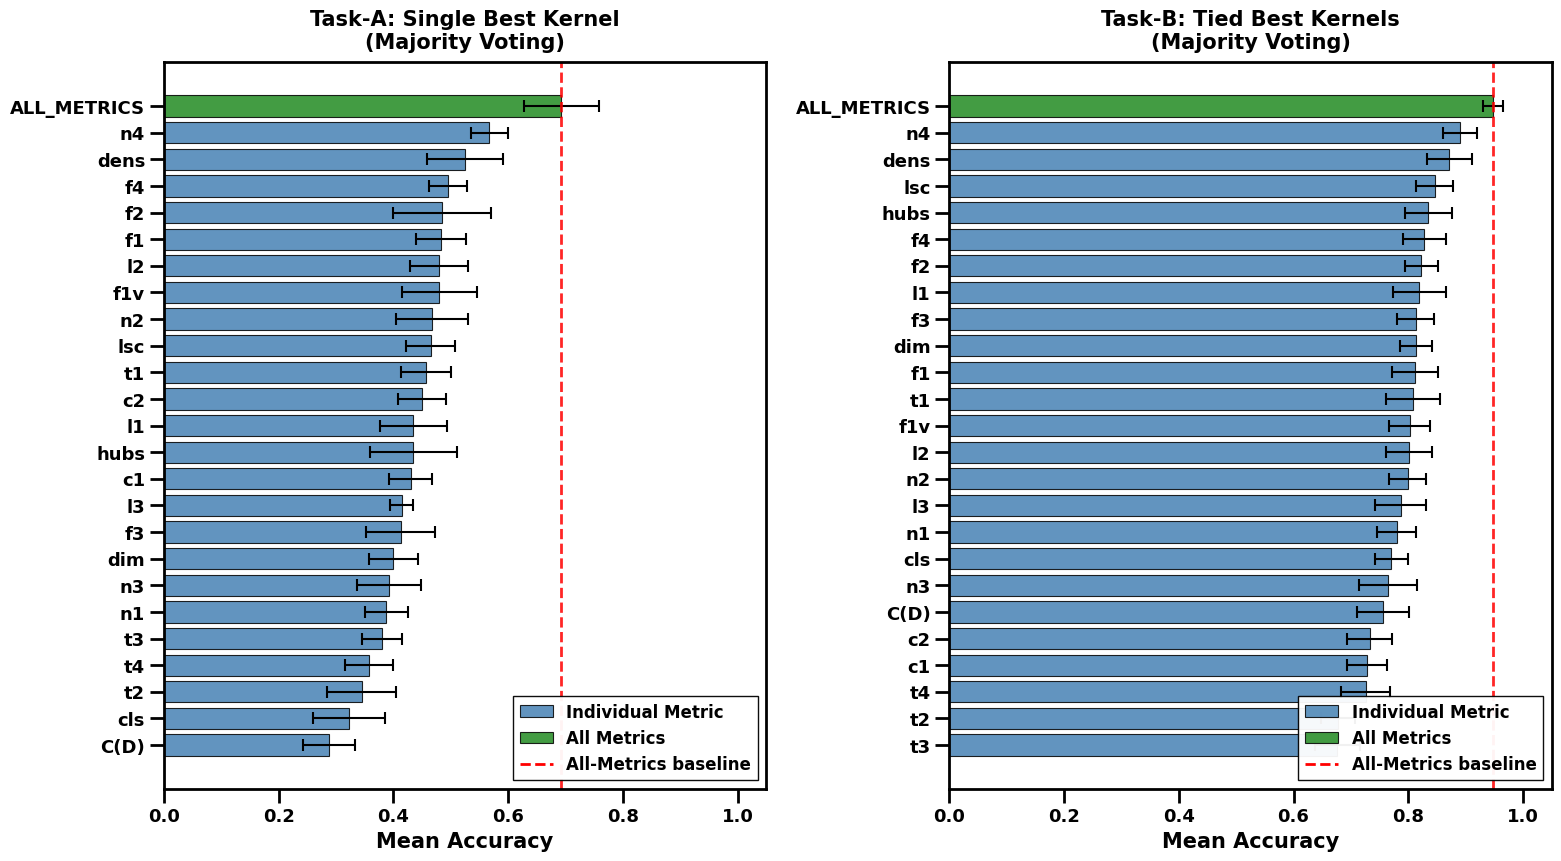

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

all_metrics_a = df_a_single[df_a_single['Metric'] == 'ALL_METRICS'].iloc[0]
all_metrics_b = df_b_single[df_b_single['Metric'] == 'ALL_METRICS'].iloc[0]

plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'axes.linewidth': 2.0,        
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.major.size': 10,
    'ytick.major.size': 10,
    'font.weight': 'bold',        
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})

fig, axes = plt.subplots(1, 2, figsize=(16, 9))  


COLOR_SINGLE = 'steelblue'
COLOR_ALL    = 'forestgreen'

def plot_panel(ax, df_plot, all_metrics_row, title):
    colors = [COLOR_ALL if m == 'ALL_METRICS' else COLOR_SINGLE 
              for m in df_plot['Metric']]
    
    ax.barh(
        range(len(df_plot)),
        df_plot['Mean_Acc'],
        xerr=df_plot['Std_Acc'],
        color=colors,
        capsize=4,
        alpha=0.85,
        edgecolor='black',        
        linewidth=0.8,
        error_kw=dict(elinewidth=1.5, ecolor='black', capthick=1.5)
    )
    
    ax.set_yticks(range(len(df_plot)))
    ax.set_yticklabels(df_plot['Metric'], fontweight='bold')
    ax.set_xlabel('Mean Accuracy', fontweight='bold')
    ax.set_title(title, fontweight='bold', pad=10)
    
    # Reference line
    ax.axvline(
        x=all_metrics_row['Mean_Acc'],
        color='red', linestyle='--', linewidth=2.0,
        alpha=0.85, label='_nolegend_'
    )
    
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)
    
    # ── Legend 
    patch_single = mpatches.Patch(
        facecolor=COLOR_SINGLE, edgecolor='black', linewidth=0.8,
        alpha=0.85, label='Individual Metric'
    )
    patch_all = mpatches.Patch(
        facecolor=COLOR_ALL, edgecolor='black', linewidth=0.8,
        alpha=0.85, label='All Metrics'
    )
    line_ref = plt.Line2D(
        [], [], color='red', linestyle='--', linewidth=2.0,
        label=f'All-Metrics baseline'
    )
    ax.legend(
        handles=[patch_single, patch_all, line_ref],
        loc='lower right',
        framealpha=0.95,
        edgecolor='black',
        fancybox=False,
        fontsize=12
    )
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)

display_map = {
    'density': 'dens',
    'clsCoef': 'cls',
    'kolmogorov': 'C(D)',
    'intrinsic': 'dim'
}

# Task-A
df_plot_a = df_a_single.copy()
df_plot_a['Metric'] = df_plot_a['Metric'].replace(display_map)
plot_panel(axes[0], df_plot_a, all_metrics_a,
           'Task-A: Single Best Kernel\n(Majority Voting)')

# Task-B
df_plot_b = df_b_single.copy()
df_plot_b['Metric'] = df_plot_b['Metric'].replace(display_map)
plot_panel(axes[1], df_plot_b, all_metrics_b,
           'Task-B: Tied Best Kernels\n(Majority Voting)')

plt.tight_layout(pad=1.5)
plt.savefig('results/majority_voting_single_vs_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Inference on Unseen Datasets

### 7.1 Train Final Models

Train the full ensemble on the entire Task-B dataset (no holdout) for deployment. Two model sets are produced: one using all 24 metrics, one using only the single best metric from the evaluation above.

In [14]:
from Qsun.Qkernels import *
from Qsun.Qencodes import *
from Qsun.Qdata import *
from src.kernel_evaluation import *
import problexity as px

In [15]:
print("=" * 70)
print("TRAIN ALL METRICS MODEL FOR TASK-B")
print("=" * 70)

scaler_b_final = StandardScaler()
X_b_scaled_final = scaler_b_final.fit_transform(X_b)

trained_models_b_final = {}
for name, clf in CLASSIFIERS.items():
    try:
        model = clone(clf)
        model.fit(X_b_scaled_final, y_b_encoded)
        trained_models_b_final[name] = model
    except Exception as e:
        print(f"  ✗ {name}: {e}")

print(f" Trained {len(trained_models_b_final)} classifiers on ALL METRICS")

TRAIN ALL METRICS MODEL FOR TASK-B
 Trained 14 classifiers on ALL METRICS


In [16]:
print("=" * 70)
print(f"TRAIN SINGLE METRIC ({best_singlemetric_b}) MODEL FOR TASK-B")
print("=" * 70)

BEST_SINGLE_METRIC = best_singlemetric_b
best_metric_idx = METRIC_NAMES.index(BEST_SINGLE_METRIC)

X_b_single = X_b[:, [best_metric_idx]]

scaler_b_single = StandardScaler()
X_b_single_scaled = scaler_b_single.fit_transform(X_b_single)

trained_models_b_single = {}
for name, clf in CLASSIFIERS.items():
    try:
        model = clone(clf)
        model.fit(X_b_single_scaled, y_b_encoded)
        trained_models_b_single[name] = model
    except Exception as e:
        print(f"  ✗ {name}: {e}")

print(f" Trained {len(trained_models_b_single)} classifiers on SINGLE METRIC ({BEST_SINGLE_METRIC})")

TRAIN SINGLE METRIC (n4) MODEL FOR TASK-B
 Trained 14 classifiers on SINGLE METRIC (n4)


### 7.2 Utility Functions

Helper functions for computing ground truth from exhaustive evaluation results and extracting top-k predictions with vote probabilities from the ensemble.

In [17]:
from src.config import *
from src.kernel_evaluation import *

In [18]:
def compute_ground_truth(df_all_results):
    ground_truth = {}
    
    for ds_name, ds_group in df_all_results.groupby('Dataset'):
        kernel_best = ds_group.groupby('Kernel')['Mean_Acc'].max()
        
        global_best_acc = kernel_best.max()
        
        best_kernels = kernel_best[kernel_best == global_best_acc].index.tolist()
        
        ground_truth[ds_name] = best_kernels
    
    return ground_truth


In [19]:
from collections import Counter

def get_top_k_predictions_ensemble(X_scaled, trained_models, label_encoder, top_k=3):
    votes = []
    for name, model in trained_models.items():
        try:
            pred_encoded = model.predict(X_scaled)[0]
            votes.append(pred_encoded)
        except Exception:
            pass

    vote_counts  = Counter(votes)
    total_votes  = len(votes)
    kernel_proba = []
    for kernel_encoded, count in vote_counts.items():
        kernel_label = str(label_encoder.inverse_transform([kernel_encoded])[0])
        probability  = count / total_votes
        kernel_proba.append((kernel_label, probability))

    kernel_proba.sort(key=lambda x: x[1], reverse=True)
    return kernel_proba[:top_k]


### 7.3 Test Dataset Preparation

7 new datasets with varying characteristics (linearly separable, non-linear, high-dimensional, imbalanced) for out-of-sample validation. All are normalized to [0, 1] and reduced to at most 4 features via PCA.

In [37]:
from sklearn.datasets import load_digits, make_moons, make_circles, make_classification
from sklearn.datasets import make_gaussian_quantiles
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import numpy as np

def prepare_dataset(X, y, name, max_features=4):
    scaler_prep = MinMaxScaler(feature_range=(0, 1))
    X_scaled = scaler_prep.fit_transform(X)
    if X_scaled.shape[1] > max_features:
        pca = PCA(n_components=max_features)
        X_scaled = pca.fit_transform(X_scaled)
        print(f"  {name}: {X.shape} → PCA → {X_scaled.shape} ({pca.explained_variance_ratio_.sum():.1%} var)")
    else:
        print(f"  {name}: {X_scaled.shape}")
    return X_scaled, y

print("=" * 70)
print("PREPARE ALL 7 TEST DATASETS")
print("=" * 70)

digits = load_digits()
mask = (digits.target == 0) | (digits.target == 1)
X_digits, y_digits = prepare_dataset(digits.data[mask], digits.target[mask], "Digits_0v1")

X_moons, y_moons = make_moons(n_samples=200, noise=0.35, random_state=42)
X_moons, y_moons = prepare_dataset(X_moons, y_moons, "Moons_n35")

X_circles, y_circles = make_circles(n_samples=200, noise=0.30, factor=0.3, random_state=42)
X_circles, y_circles = prepare_dataset(X_circles, y_circles, "Circles")

X_synth, y_synth = make_classification(
    n_samples=200, n_features=4, n_informative=3,
    n_redundant=1, flip_y=0.1, random_state=42
)
X_synth, y_synth = prepare_dataset(X_synth, y_synth, "Synthetic")

X_gauss, y_gauss = make_gaussian_quantiles(
    n_samples=150, n_features=3, n_classes=2, random_state=42
)
X_gauss, y_gauss = prepare_dataset(X_gauss, y_gauss, "GaussianQuantiles")

np.random.seed(42)
n_per_ring = 50
X_rings, y_rings = [], []
for i, r in enumerate([0.3, 0.6, 0.9]):
    theta = np.random.uniform(0, 2*np.pi, n_per_ring)
    X_ring = np.column_stack([r*np.cos(theta), r*np.sin(theta)])
    X_ring += np.random.normal(0, 0.03, X_ring.shape)
    X_rings.append(X_ring)
    y_rings.extend([i % 2] * n_per_ring)
X_multiring = np.vstack(X_rings)
y_multiring = np.array(y_rings)
X_multiring, y_multiring = prepare_dataset(X_multiring, y_multiring, "MultiRing")

X_imbal, y_imbal = make_classification(
    n_samples=100, n_features=2, n_informative=2, n_redundant=0,
    weights=[0.8, 0.2], class_sep=1.5, random_state=42
)
X_imbal, y_imbal = prepare_dataset(X_imbal, y_imbal, "Imbalanced")

all_test_datasets = {
    'Digits_0v1':        (X_digits,    y_digits),
    'Moons_n35':         (X_moons,     y_moons),
    'Circles':           (X_circles,   y_circles),
    'Synthetic':         (X_synth,     y_synth),
    'GaussianQuantiles': (X_gauss,     y_gauss),
    'MultiRing':         (X_multiring, y_multiring),
    'Imbalanced':        (X_imbal,     y_imbal),
}

print(f"\n Prepared {len(all_test_datasets)} test datasets")


PREPARE ALL 7 TEST DATASETS
  Digits_0v1: (360, 64) → PCA → (360, 4) (71.6% var)
  Moons_n35: (200, 2)
  Circles: (200, 2)
  Synthetic: (200, 4)
  GaussianQuantiles: (150, 3)
  MultiRing: (150, 2)
  Imbalanced: (100, 2)

 Prepared 7 test datasets


### 7.4 Complexity Metrics for Test Datasets

Compute the 24 complexity metrics for each test dataset (averaged over 10 runs to reduce stochastic variance). This produces the input feature matrix for prediction.

In [38]:
print("\n" + "=" * 70)
print(f"{'Dataset':<20} {'Samples':>8} {'Features':>10} {'Class 0':>8} {'Class 1':>8} {'Balance':>8}")
print("-" * 70)

for name, (X, y) in all_test_datasets.items():
    cls = np.bincount(y)
    bal = min(cls) / max(cls)
    print(f"{name:<20} {len(y):>8} {X.shape[1]:>10} {cls[0]:>8} {cls[1]:>8} {bal:>8.2f}")

print("=" * 70)
print("\n" + "=" * 70)
print("COMPUTE COMPLEXITY METRICS FOR ALL 7 TEST DATASETS")
print("=" * 70)

complexities_test = {}

for name, (X, y) in all_test_datasets.items():
    print(f"\n  {name}: shape={X.shape}")
    
    complexities_runs = []
    for i in range(N_RUNS):
        seed = 42 + i
        
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y,
            test_size=TEST_SIZE,
            random_state=seed,
            stratify=y
        )
        
        scaler = MinMaxScaler(feature_range=(0, 1))
        X_tr = scaler.fit_transform(X_tr)
        
        cc = px.ComplexityCalculator()
        cc.fit(X_tr, y_tr)
        results = list(cc.complexity)
        results.append(kolmogorov_complex(X_tr)['best_bytes'])
        results.append(intrinsic_dim_from_cov(X_tr))
        complexities_runs.append(results)
    
    complexities_runs = np.array(complexities_runs)
    complexities_test[name] = np.mean(complexities_runs, axis=0)
    print(f"     Computed {len(METRIC_NAMES)} metrics")

df_all_test_complexity = pd.DataFrame(complexities_test, index=METRIC_NAMES).T
print(f"\n Complexity matrix: {df_all_test_complexity.shape}")
print(df_all_test_complexity.round(4).to_string())



Dataset               Samples   Features  Class 0  Class 1  Balance
----------------------------------------------------------------------
Digits_0v1                360          4      178      182     0.98
Moons_n35                 200          2      100      100     1.00
Circles                   200          2      100      100     1.00
Synthetic                 200          4      103       97     0.94
GaussianQuantiles         150          3       75       75     1.00
MultiRing                 150          2      100       50     0.50
Imbalanced                100          2       80       20     0.25

COMPUTE COMPLEXITY METRICS FOR ALL 7 TEST DATASETS

  Digits_0v1: shape=(360, 4)
     Computed 24 metrics

  Moons_n35: shape=(200, 2)
     Computed 24 metrics

  Circles: shape=(200, 2)
     Computed 24 metrics

  Synthetic: shape=(200, 4)
     Computed 24 metrics

  GaussianQuantiles: shape=(150, 3)
     Computed 24 metrics

  MultiRing: shape=(150, 2)
     Computed 24 metrics



### 7.5 Ground Truth: Exhaustive Evaluation

Brute-force evaluation of all 9 encoding circuits × 3 classifiers × 10 random splits on each test dataset. This establishes the true best encoding circuit(s) for comparison against predictions.

In [45]:
N_VERIFY_RUNS = 10
ML_MODELS = list(MODEL_REGISTER.keys())
print("\n" + "=" * 70)
print(f"GROUND TRUTH: ALL KERNELS × ALL MODELS ({N_VERIFY_RUNS} runs)")
print("=" * 70)

all_results_7 = []

for ds_name, (X, y) in all_test_datasets.items():
    print(f"\n{'='*70}\n  {ds_name}\n{'='*70}")
    
    kernel_model_scores = {k: {m: [] for m in ML_MODELS} for k in ENCODING_REGISTER.keys()}
    
    for run in range(N_VERIFY_RUNS):
        seed = 42 + run
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, random_state=seed, stratify=y
        )
        scaler_pi = MinMaxScaler(feature_range=(0, np.pi))
        X_tr_pi = scaler_pi.fit_transform(X_tr)
        X_te_pi = scaler_pi.transform(X_te)
        
        for kernel_name in ENCODING_REGISTER.keys():
            try:
                K_train, K_test = kernel_matrix(X_tr_pi, X_te_pi, kernel_name, n_layers=2)
                for model_name in ML_MODELS:
                    try:
                        result = evaluate_kernel(K_train, K_test, y_tr, y_te, kernel_name, model_name)
                        kernel_model_scores[kernel_name][model_name].append(result.test_accuracy)
                    except: pass
            except: pass
    
    print(f"\n{'Kernel':<22} {'SVM':>12} {'GPC':>12} {'KRC':>12} {'Avg':>12}")
    print("-" * 70)
    
    for kernel_name in ENCODING_REGISTER.keys():
        row = f"{kernel_name:<22}"
        model_means = []
        for model_name in ML_MODELS:
            scores = kernel_model_scores[kernel_name][model_name]
            if scores:
                m, s = np.mean(scores), np.std(scores)
                model_means.append(m)
                row += f" {m:.4f}±{s:.2f}"
                all_results_7.append({
                    'Dataset': ds_name, 'Kernel': kernel_name,
                    'Model': model_name, 'Mean_Acc': m, 'Std_Acc': s
                })
            else:
                row += f" {'N/A':>12}"
        if model_means:
            row += f" {np.mean(model_means):.4f}"
        print(row)

df_results_7 = pd.DataFrame(all_results_7)


GROUND TRUTH: ALL KERNELS × ALL MODELS (10 runs)

  Digits_0v1

Kernel                          SVM          GPC          KRC          Avg
----------------------------------------------------------------------
YZ_CX                  0.4931±0.07 0.4861±0.07 0.4903±0.07 0.4898
HighDim                1.0000±0.00 1.0000±0.00 1.0000±0.00 1.0000
HZY_CZ                 0.9986±0.00 0.9972±0.01 0.9986±0.00 0.9981
Chebyshev              0.5528±0.04 0.5694±0.04 0.5597±0.04 0.5606
ParamZFeatureMap       0.7042±0.05 0.7236±0.04 0.7111±0.05 0.7130
SeparableRX            0.9986±0.00 0.9944±0.01 0.9972±0.01 0.9968
HardwareEfficientRx    1.0000±0.00 1.0000±0.00 1.0000±0.00 1.0000
ZFeatureMap            0.9722±0.02 0.9639±0.02 0.9792±0.02 0.9718
ZZFeatureMap           0.8972±0.04 0.8556±0.06 0.8889±0.03 0.8806

  Moons_n35

Kernel                          SVM          GPC          KRC          Avg
----------------------------------------------------------------------
YZ_CX                  0.4825±0.10 

In [46]:
ground_truth_7 = compute_ground_truth(df_results_7)

print("\n" + "=" * 70)
print("BEST KERNELS PER DATASET")
print("=" * 70)

for ds_name, best_kernels in ground_truth_7.items():
    ds_res = df_results_7[df_results_7['Dataset'] == ds_name]
    kernel_best = ds_res.groupby('Kernel')['Mean_Acc'].max()
    best_acc = kernel_best.max()
    print(f"\n{ds_name}: best={best_acc:.4f}")
    for k in best_kernels:
        print(f"    {k}: {kernel_best[k]:.4f}")


BEST KERNELS PER DATASET

Circles: best=0.8800
    HighDim: 0.8800

Digits_0v1: best=1.0000
    HardwareEfficientRx: 1.0000
    HighDim: 1.0000

GaussianQuantiles: best=0.9400
    HardwareEfficientRx: 0.9400

Imbalanced: best=0.9950
    HZY_CZ: 0.9950
    HighDim: 0.9950

Moons_n35: best=0.8600
    HighDim: 0.8600

MultiRing: best=0.9867
    ZFeatureMap: 0.9867

Synthetic: best=0.8625
    HardwareEfficientRx: 0.8625
    HighDim: 0.8625
    SeparableRX: 0.8625


### 7.6 Predictions vs Ground Truth

Compare framework recommendations against ground truth using Top-1 and Top-3 hit rates. Top-3 reflects the practical use case where a user evaluates 2–3 recommended encoding circuits rather than all 9.

In [47]:
print("\n" + "=" * 70)
print("PREDICTIONS VS GROUND TRUTH (ALL 7 DATASETS)")
print("=" * 70)

predictions_7 = []

for ds_name in all_test_datasets.keys():
    # All metrics
    X_new = df_all_test_complexity.loc[ds_name, feature_cols].values.reshape(1, -1)
    X_new_scaled = scaler_b_final.transform(X_new)
    top3_all = get_top_k_predictions_ensemble(X_new_scaled, trained_models_b_final, le_b, top_k=3)

    # Single metric
    X_single = np.array([[df_all_test_complexity.loc[ds_name, BEST_SINGLE_METRIC]]])
    X_single_scaled = scaler_b_single.transform(X_single)
    top3_single = get_top_k_predictions_ensemble(X_single_scaled, trained_models_b_single, le_b, top_k=3)

    gt = ground_truth_7[ds_name]
    mv_top1 = top3_all[0][0] in gt
    mv_top3 = any(k in gt for k, _ in top3_all)
    sg_top1 = top3_single[0][0] in gt
    sg_top3 = any(k in gt for k, _ in top3_single)

    predictions_7.append({
        'Dataset':            ds_name,
        'GT_Best':            gt,
        'MV_All_Top1':        top3_all[0][0],
        'MV_All_Top3':        [k for k, _ in top3_all],
        'MV_Single_Top1':     top3_single[0][0],
        'MV_Single_Top3':     [k for k, _ in top3_single],
        'MV_All_Top1_Hit':    mv_top1,
        'MV_All_Top3_Hit':    mv_top3,
        'MV_Single_Top1_Hit': sg_top1,
        'MV_Single_Top3_Hit': sg_top3,
    })

    print(f"\n{ds_name}:")
    print(f"  GT:             {gt}")
    print(f"  MV All  Top-3:  {[k for k,_ in top3_all]}  Top-1={'✓' if mv_top1 else '✗'} Top-3={'✓' if mv_top3 else '✗'}")
    print(f"  MV Single Top-3:{[k for k,_ in top3_single]}  Top-1={'✓' if sg_top1 else '✗'} Top-3={'✓' if sg_top3 else '✗'}")



PREDICTIONS VS GROUND TRUTH (ALL 7 DATASETS)

Digits_0v1:
  GT:             ['HardwareEfficientRx', 'HighDim']
  MV All  Top-3:  ['SeparableRX', 'HZY_CZ', 'HighDim']  Top-1=✗ Top-3=✓
  MV Single Top-3:['SeparableRX', 'HighDim', 'HZY_CZ']  Top-1=✗ Top-3=✓

Moons_n35:
  GT:             ['HighDim']
  MV All  Top-3:  ['HighDim', 'ZFeatureMap', 'ZZFeatureMap']  Top-1=✓ Top-3=✓
  MV Single Top-3:['HardwareEfficientRx', 'HighDim', 'ZFeatureMap']  Top-1=✗ Top-3=✓

Circles:
  GT:             ['HighDim']
  MV All  Top-3:  ['HardwareEfficientRx', 'SeparableRX', 'ZFeatureMap']  Top-1=✗ Top-3=✗
  MV Single Top-3:['ZFeatureMap', 'SeparableRX', 'ZZFeatureMap']  Top-1=✗ Top-3=✗

Synthetic:
  GT:             ['HardwareEfficientRx', 'HighDim', 'SeparableRX']
  MV All  Top-3:  ['HighDim', 'SeparableRX', 'HardwareEfficientRx']  Top-1=✓ Top-3=✓
  MV Single Top-3:['HighDim', 'HardwareEfficientRx']  Top-1=✓ Top-3=✓

GaussianQuantiles:
  GT:             ['HardwareEfficientRx']
  MV All  Top-3:  ['ZFeatureMap

In [48]:
df_pred_7 = pd.DataFrame(predictions_7)
n = len(df_pred_7)

print("\n" + "=" * 70)
print(f"FINAL SUMMARY ({n} DATASETS)")
print("=" * 70)
for label, col_top1, col_top3 in [
    ("Majority Voting (All Metrics)",                    'MV_All_Top1_Hit',    'MV_All_Top3_Hit'),
    (f"Majority Voting (Single - {BEST_SINGLE_METRIC})", 'MV_Single_Top1_Hit', 'MV_Single_Top3_Hit'),
]:
    t1 = df_pred_7[col_top1].sum()
    t3 = df_pred_7[col_top3].sum()
    print(f"\n{label}:")
    print(f"  Top-1: {t1}/{n} ({t1/n*100:.1f}%)")
    print(f"  Top-3: {t3}/{n} ({t3/n*100:.1f}%)")


FINAL SUMMARY (7 DATASETS)

Majority Voting (All Metrics):
  Top-1: 3/7 (42.9%)
  Top-3: 6/7 (85.7%)

Majority Voting (Single - n4):
  Top-1: 2/7 (28.6%)
  Top-3: 5/7 (71.4%)
